# PASSO 3 - Treinamento de Modelo (Multinomial Naive Bayes)
Nesse passo, vamos treinar modelos Multinomial Naive Bayes para cada traço de personalidade MBTI, utilizando a representação TF-IDF.

> #### Observação: Não utilizamos Word2Vec neste notebook
> O **Multinomial Naive Bayes** exige que os dados de entrada sejam não-negativos (como o *TF-IDF*). Como os embeddings do **Word2Vec** geram vetores com valores negativos, o modelo trava com um erro de execução (`ValueError`). Por isso, os experimentos deste notebook focarão **apenas no TF-IDF**.

## 0. Setup
Importar os pacotes necessários para rodar o resto do código.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import f1_score
from pipeline.smote_oversampling import SMOTEOversampler
from pipeline.machine_learning_algorithms.multinomial_naive_bayes import MultinomialNaiveBayesClassifier

# Tamanho do subset humano original no passo 2 (antes da augmentação por SLM).
# Validado em cada experimento "base" para garantir que o fatiamento [:N_HUMAN_POSTS]
# realmente corresponde aos posts humanos e não inclui amostras augmentadas.
N_HUMAN_POSTS = 6940
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train_datasets"
TEST_DIR = DATA_DIR / "test_datasets"
MODELS_DIR = Path("models/multinomial_naive_bayes")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

def divide_mbti(y_series):
    """Converte a string MBTI (ex: 'INFJ') em 4 colunas binárias (I/E, N/S, T/F, J/P)."""
    y_series = pd.Series(y_series).reset_index(drop=True)
    y_df = pd.DataFrame()
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)
    return y_df

def load_train_test(embedding):
    """Carrega x_train/x_test (para um embedding) e y_train/y_test (comuns a todos)."""
    x_train = pd.read_pickle(TRAIN_DIR / f"x_train_{embedding}.pkl")
    x_test = pd.read_pickle(TEST_DIR / f"x_test_{embedding}.pkl")
    y_train = pd.Series(pd.read_pickle(TRAIN_DIR / "y_train.pkl"))
    y_test = pd.Series(pd.read_pickle(TEST_DIR / "y_test.pkl"))
    return x_train, x_test, y_train, y_test

def save_models(clf, label):
    """Salva os 4 submodelos (um por traço MBTI) com sufixo `label` usando joblib."""
    for key, model in clf.models.items():
        path = MODELS_DIR / f"{key}_{label}.pkl"
        joblib.dump(model, str(path))
        print(f"Salvo: {path}")

def run_experiment(embedding, label, *, use_smote=True, human_only=False):
    """Carrega dados, (opcionalmente) aplica SMOTE, treina, avalia e salva os modelos.

    - `human_only=True`: restringe o treino aos posts humanos originais (sem augmentação SLM).
    - `use_smote=False`: não aplica oversampling (baseline sem SMOTE).
    Retorna o classificador treinado (predições ficam disponíveis via clf.predict)."""
    x_train, x_test, y_train, y_test = load_train_test(embedding)

    if human_only:
        assert len(x_train) >= N_HUMAN_POSTS, (
            f"x_train ({len(x_train)}) menor que N_HUMAN_POSTS ({N_HUMAN_POSTS}); "
            "verifique a ordem de concatenação no passo 2."
        )
        x_train = x_train[:N_HUMAN_POSTS]
        y_train = y_train[:N_HUMAN_POSTS]

    if use_smote:
        x_train, y_train = SMOTEOversampler(random_state=42).fit_resample(x_train, y_train)

    y_train_4cols = divide_mbti(y_train)
    y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

    clf = MultinomialNaiveBayesClassifier()
    clf.fit(x_train, y_train_4cols)
    clf.evaluate(x_test, y_test_4cols)
    save_models(clf, label)
    return clf

## 1. Baseline
Treina apenas com os posts humanos originais, sem aplicação de técnicas de balanceamento de classes. Serve como parâmetro de controle para avaliar o ganho das otimizações posteriores.

#### TF-IDF

In [2]:
tfidf_baseline = run_experiment('tfidf', 'tfidf_baseline', use_smote=False, human_only=True)


Evaluation for dimension: I_E
Accuracy: 0.7683

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       401
           1       0.77      1.00      0.87      1334

    accuracy                           0.77      1735
   macro avg       0.38      0.50      0.43      1735
weighted avg       0.59      0.77      0.67      1735


Evaluation for dimension: N_S
Accuracy: 0.8617

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       240
           1       0.86      1.00      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.43      0.50      0.46      1735
weighted avg       0.74      0.86      0.80      1735


Evaluation for dimension: T_F
Accuracy: 0.7614

              precision    recall  f1-score   support

           0       0.74      0.86      0.80       939
           1       0.80      0.64      0.71       796

    accuracy                       

## 2. Baseline + SMOTE
Treina com um over-sampling SMOTE dos dados originais. Gerando amostras sintéticas baseadas nas classes minoritárias, visando reduzir o viés do modelo.

#### TF-IDF

In [3]:
tfidf_smote = run_experiment('tfidf', 'tfidf_smote', use_smote=True, human_only=True)

Original dataset shape: X=(6940, 10000), y=(6940,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)

Evaluation for dimension: I_E
Accuracy: 0.7308

              precision    recall  f1-score   support

           0       0.39      0.31      0.35       401
           1       0.81      0.86      0.83      1334

    accuracy                           0.73      1735
   macro avg       0.60      0.58      0.59      1735
weighted avg       0.71      0.73      0.72      1735


Evaluation for dimension: N_S
Accuracy: 0.8398

              precision    recall  f1-score   support

           0       0.40      0.30      0.34       240
           1       0.89      0.93      0.91      1495

    accuracy                           0.84      1735
   macro avg       0.64      0.61      0.63      1735
weighted avg       0.82      0.84      0.83      1735


Evaluation for dimension: T_F
Accuracy: 0.7182

              precision    recall  f1-score   support

           0       0.78      0.67      

## 3. Baseline + SMOTE + SLM
Treina com um over-sampling e um augmentation de SLM (qwen) dos dados originais. O objetivo é testar se a variabilidade introduzida pela IA melhora a capacidade de generalização do modelo.

#### TF-IDF

In [4]:
tfidf_aug = run_experiment('tfidf', 'tfidf_aug', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 10000), y=(9322,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)

Evaluation for dimension: I_E
Accuracy: 0.7579

              precision    recall  f1-score   support

           0       0.41      0.11      0.17       401
           1       0.78      0.95      0.86      1334

    accuracy                           0.76      1735
   macro avg       0.59      0.53      0.51      1735
weighted avg       0.69      0.76      0.70      1735


Evaluation for dimension: N_S
Accuracy: 0.8565

              precision    recall  f1-score   support

           0       0.35      0.05      0.08       240
           1       0.87      0.99      0.92      1495

    accuracy                           0.86      1735
   macro avg       0.61      0.52      0.50      1735
weighted avg       0.79      0.86      0.81      1735


Evaluation for dimension: T_F
Accuracy: 0.7349

              precision    recall  f1-score   support

           0       0.75      0.76      

## 4. Análise Comparativa
Avaliação da performance preditiva dos modelos, comparando os resultados das predições de cada experimento.

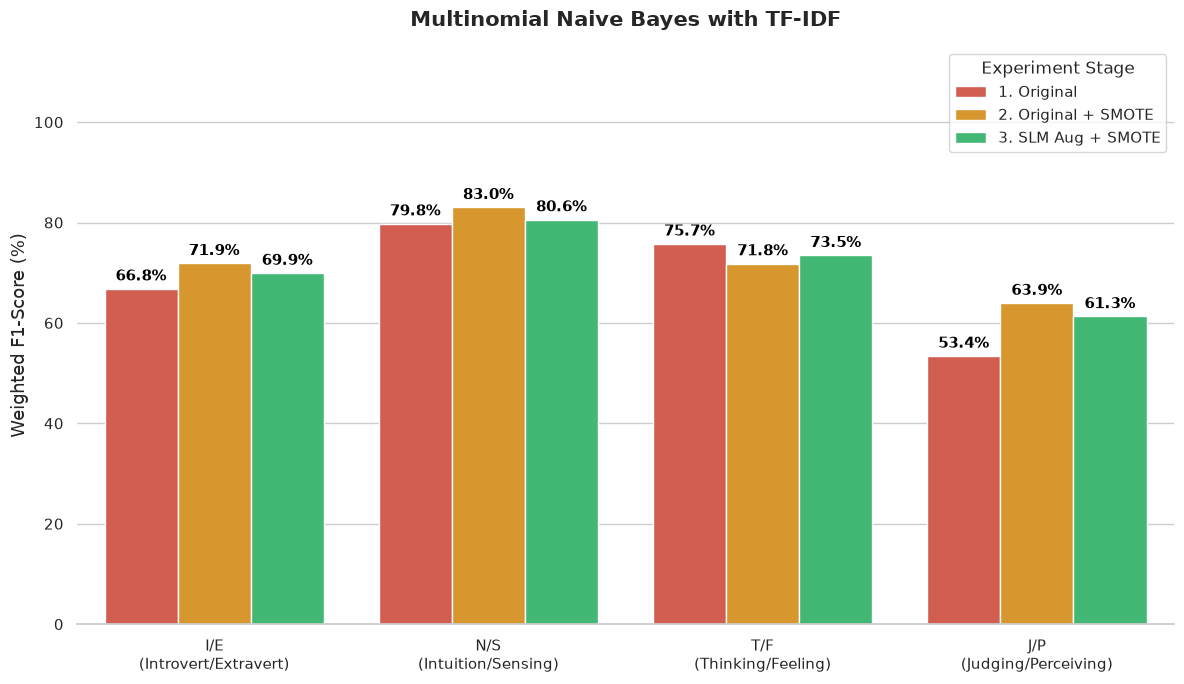

In [5]:
x_test_tfidf = pd.read_pickle(TEST_DIR / "x_test_tfidf.pkl")
y_test_raw = pd.Series(pd.read_pickle(TEST_DIR / "y_test.pkl"))
y_test_4cols = divide_mbti(y_test_raw)

pred_tfidf_base = tfidf_baseline.predict(x_test_tfidf)
pred_tfidf_smote = tfidf_smote.predict(x_test_tfidf)
pred_tfidf_aug = tfidf_aug.predict(x_test_tfidf)

colunas = ['I_E', 'N_S', 'T_F', 'J_P']
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)',
               'T/F\n(Thinking/Feeling)', 'J/P\n(Judging/Perceiving)']

experiments = [
    ('1. Original',         pred_tfidf_base),
    ('2. Original + SMOTE', pred_tfidf_smote),
    ('3. SLM Aug + SMOTE',  pred_tfidf_aug),
]

dados = [
    {'Axis': nomes_eixos[i], 'F1 (%)': f1_score(y_test_4cols[col], pred[col], average='weighted', zero_division=0) * 100,
     'Method': method}
    for method, pred in experiments
    for i, col in enumerate(colunas)
]
df_plot = pd.DataFrame(dados)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
paleta = ['#e74c3c', '#f39c12', '#2ecc71']

axis = sns.barplot(
    data=df_plot,
    x="Axis",
    y="F1 (%)",
    hue="Method",
    palette=paleta
)

axis.set_title(
    "Multinomial Naive Bayes with TF-IDF",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axis.set_ylim(0, 115)
axis.set_ylabel("Weighted F1-Score (%)", fontsize=13)
axis.set_xlabel("")

for bar in axis.patches:
    height = bar.get_height()
    if height > 0:
        axis.annotate(
            f"{height:.1f}%",
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center", va="baseline", fontsize=11, fontweight="bold",
            color="black", xytext=(0, 6), textcoords="offset points"
        )

axis.legend(title="Experiment Stage", fontsize=11, loc="upper right")

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()